# Gibbs Sampling

## Overview

**Gibbs Sampling** is a Markov Chain Monte Carlo (MCMC) algorithm for drawing samples from a multivariate distribution when direct sampling is difficult but sampling from each **conditional distribution** is tractable.

### Algorithm
Given a joint distribution $p(x_1, x_2, \ldots, x_n)$, initialize all variables and then iterate:

$$x_i^{(t+1)} \sim p\left(x_i \mid x_1^{(t+1)}, \ldots, x_{i-1}^{(t+1)}, x_{i+1}^{(t)}, \ldots, x_n^{(t)}\right)$$

### Example: Bivariate Normal Distribution

We sample from $p(x, y)$ — a 2D Gaussian with correlation $\rho$ — using the conditionals:

$$x \mid y \sim \mathcal{N}\!\left(\mu_x + \rho\frac{\sigma_x}{\sigma_y}(y - \mu_y),\ \sigma_x^2(1 - \rho^2)\right)$$

$$y \mid x \sim \mathcal{N}\!\left(\mu_y + \rho\frac{\sigma_y}{\sigma_x}(x - \mu_x),\ \sigma_y^2(1 - \rho^2)\right)$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import multivariate_normal

np.random.seed(42)

## Gibbs Sampler Implementation

In [3]:
def gibbs_sampler_bivariate_normal(
    n_samples: int,
    mu: np.ndarray,
    sigma: np.ndarray,
    rho: float,
    burn_in: int = 500,
) -> np.ndarray:
    """
    Gibbs sampler for a bivariate normal distribution.

    Parameters
    ----------
    n_samples : int
        Number of samples to draw (after burn-in).
    mu : array of shape (2,)
        Mean vector [mu_x, mu_y].
    sigma : array of shape (2,)
        Standard deviations [sigma_x, sigma_y].
    rho : float
        Correlation coefficient (-1 < rho < 1).
    burn_in : int
        Number of initial samples to discard.

    Returns
    -------
    samples : ndarray of shape (n_samples, 2)
        Drawn samples [x, y].
    """
    mu_x, mu_y = mu
    sigma_x, sigma_y = sigma

    # Conditional distribution parameters (derived analytically)
    # x | y ~ N(mu_x|y, var_x|y)
    # y | x ~ N(mu_y|x, var_y|x)
    var_x_given_y = sigma_x**2 * (1 - rho**2)
    var_y_given_x = sigma_y**2 * (1 - rho**2)

    samples = np.empty((n_samples, 2))
    x, y = mu_x, mu_y  # initialise at the mean

    total_iters = n_samples + burn_in
    sample_idx = 0

    for i in range(total_iters):
        # Sample x | y
        mu_x_given_y = mu_x + rho * (sigma_x / sigma_y) * (y - mu_y)
        x = np.random.normal(mu_x_given_y, np.sqrt(var_x_given_y))

        # Sample y | x
        mu_y_given_x = mu_y + rho * (sigma_y / sigma_x) * (x - mu_x)
        y = np.random.normal(mu_y_given_x, np.sqrt(var_y_given_x))

        if i >= burn_in:
            samples[sample_idx] = [x, y]
            sample_idx += 1

    return samples


# --- Parameters ---
mu    = np.array([2.0, -1.0])
sigma = np.array([1.5, 0.8])
rho   = 0.75
N     = 3000

samples = gibbs_sampler_bivariate_normal(N, mu, sigma, rho, burn_in=500)
print(f"Collected {len(samples)} samples")
print(f"Sample mean:  {samples.mean(axis=0).round(3)}  (true: {mu})")
print(f"Sample std:   {samples.std(axis=0).round(3)}   (true: {sigma})")
print(f"Sample corr:  {np.corrcoef(samples.T)[0, 1]:.3f}  (true: {rho})")

Collected 3000 samples
Sample mean:  [ 1.956 -1.023]  (true: [ 2. -1.])
Sample std:   [1.474 0.79 ]   (true: [1.5 0.8])
Sample corr:  0.736  (true: 0.75)


## Scatter Plots

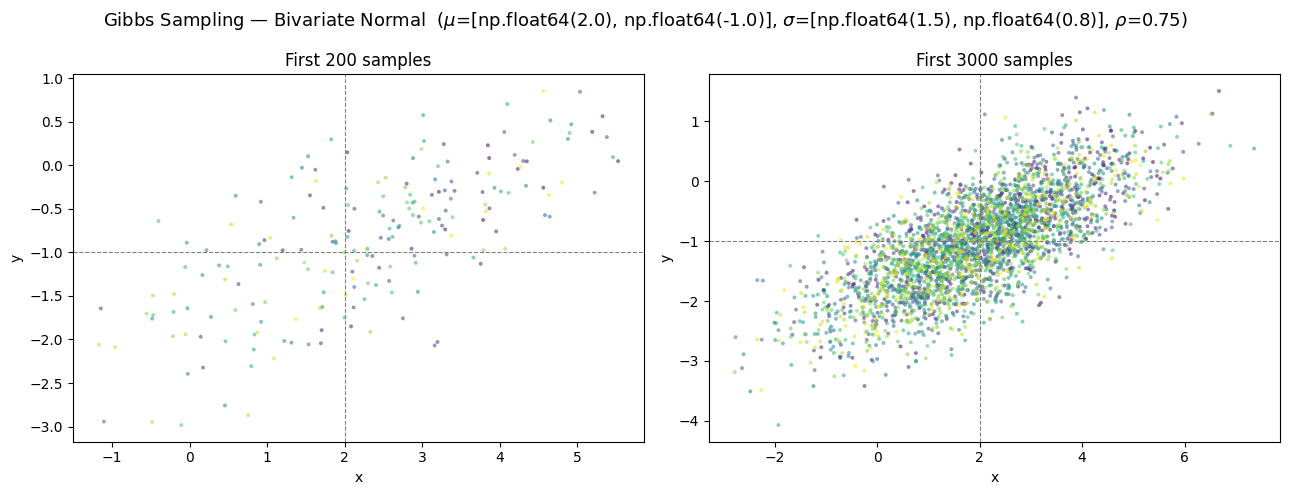

In [4]:
# True distribution contours
cov = np.array([[sigma[0]**2, rho * sigma[0] * sigma[1]],
                [rho * sigma[0] * sigma[1], sigma[1]**2]])
rv  = multivariate_normal(mean=mu, cov=cov)

x_grid = np.linspace(mu[0] - 4*sigma[0], mu[0] + 4*sigma[0], 200)
y_grid = np.linspace(mu[1] - 4*sigma[1], mu[1] + 4*sigma[1], 200)
X, Y   = np.meshgrid(x_grid, y_grid)
Z      = rv.pdf(np.dstack([X, Y]))

# ── Figure 1: Scatter + contour overlay ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Gibbs Sampling — Bivariate Normal  "
             rf"($\mu$={list(mu)}, $\sigma$={list(sigma)}, $\rho$={rho})",
             fontsize=13)

for ax, n in zip(axes, [200, N]):
    s = samples[:n]
    # ax.contour(X, Y, Z, levels=6, colors="crimson", linewidths=1, alpha=0.7)
    sc = ax.scatter(s[:, 0], s[:, 1], c=np.arange(n), cmap="viridis",
                    s=8, alpha=0.55, linewidths=0)
    # plt.colorbar(sc, ax=ax, label="Sample index")
    ax.set_title(f"First {n} samples")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axhline(mu[1], color="grey", lw=0.8, ls="--")
    ax.axvline(mu[0], color="grey", lw=0.8, ls="--")

plt.tight_layout()
plt.show()

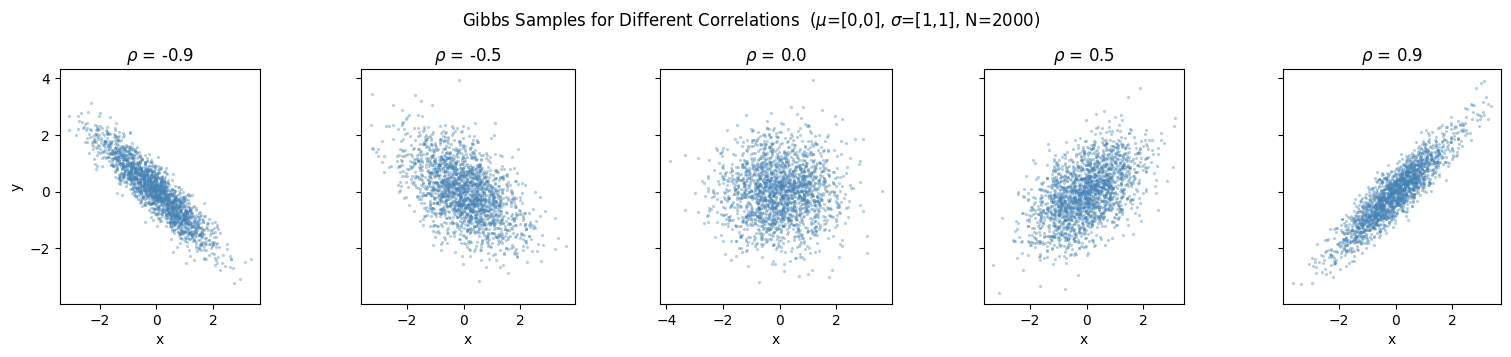

In [5]:
# ── Figure 2: Effect of correlation ──────────────────────────────────────────
rho_values = [-0.9, -0.5, 0.0, 0.5, 0.9]
fig, axes = plt.subplots(1, len(rho_values), figsize=(16, 3.5), sharey=True)
fig.suptitle("Gibbs Samples for Different Correlations  "
             r"($\mu$=[0,0], $\sigma$=[1,1], N=2000)", fontsize=12)

for ax, r in zip(axes, rho_values):
    s = gibbs_sampler_bivariate_normal(2000, np.zeros(2), np.ones(2), r, burn_in=300)
    ax.scatter(s[:, 0], s[:, 1], s=5, alpha=0.4, color="steelblue", linewidths=0)
    ax.set_title(rf"$\rho$ = {r}")
    ax.set_xlabel("x")
    ax.set_aspect("equal")

axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

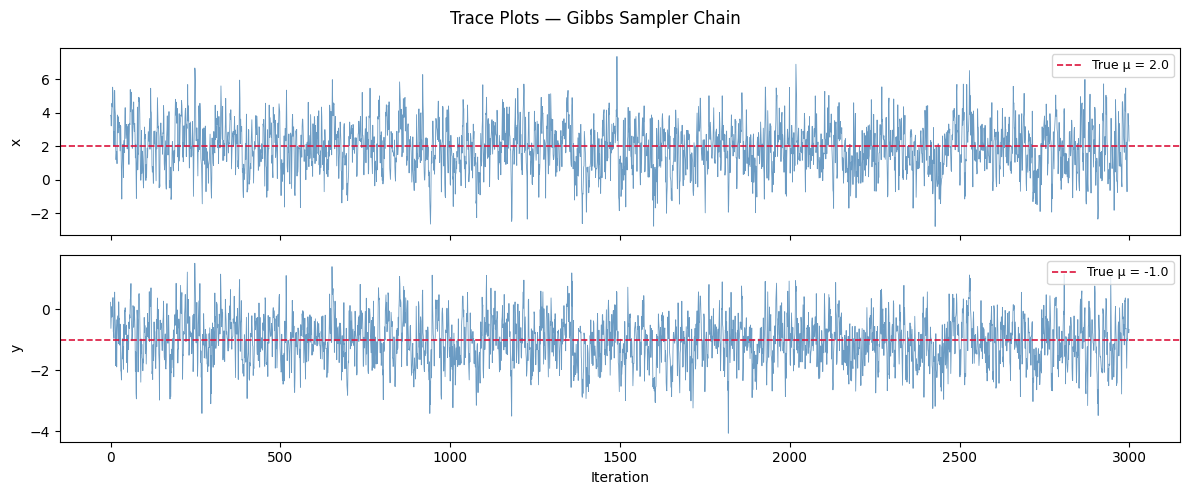

In [6]:
# ── Figure 3: Trace plots (convergence diagnostics) ──────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
fig.suptitle("Trace Plots — Gibbs Sampler Chain", fontsize=12)

for ax, dim, label in zip(axes, [0, 1], ["x", "y"]):
    ax.plot(samples[:, dim], lw=0.6, alpha=0.8, color="steelblue")
    ax.axhline(mu[dim], color="crimson", lw=1.2, ls="--", label=f"True μ = {mu[dim]}")
    ax.set_ylabel(label)
    ax.legend(loc="upper right", fontsize=9)

axes[1].set_xlabel("Iteration")
plt.tight_layout()
plt.show()

In [7]:
X = np.random.uniform(-2, 2, size=1000)
Y = X ** 2

In [8]:
X,Y

(array([ 1.32747446e+00,  1.52657502e+00, -2.66998305e-01, -5.01247917e-01,
         4.50795788e-01, -1.76810222e+00,  7.65292642e-01,  1.12915042e+00,
        -4.10232291e-01, -1.30153660e+00, -1.88472650e+00,  5.48982398e-01,
        -9.24026373e-01, -1.44441652e-01, -4.54577913e-01, -1.30046082e+00,
         3.34746738e-02, -1.61625909e-01,  4.96590491e-01, -9.92460022e-01,
        -1.14144368e+00,  1.25738024e+00,  8.08768980e-01,  1.08882581e+00,
        -1.50684075e+00, -1.10384143e+00,  3.02126065e-01,  1.42880539e+00,
         1.56845857e+00,  1.32763985e+00, -1.82640822e+00,  1.28351674e+00,
         1.59636471e+00, -1.77300364e+00, -3.34876425e-01,  1.46441293e-01,
        -1.06899851e+00,  6.67426241e-02,  1.54382315e+00,  1.46777003e+00,
         1.75934913e+00, -6.35608064e-02, -3.57732219e-01,  6.63151276e-01,
        -3.32957690e-01, -1.83222162e+00,  8.79685809e-01, -8.76064235e-01,
        -1.80365875e+00, -1.91751569e+00,  1.72544507e+00, -9.91695965e-01,
        -2.0